# 7주차: 최적화 알고리즘
## — DataLoader, Momentum, Adam, LR Scheduler

> **이전 주차 복습**: 6주차에서 Bias/Variance 진단, L2 정규화, Dropout, He/Xavier 초기화, Vanishing Gradient를 배웠습니다.  
> 오늘은 **"어떻게 더 빠르고 안정적으로 학습하는가"** 에 집중합니다.  
> 지금까지 사용한 기본 경사하강법(SGD)의 한계를 이해하고, 더 나은 최적화 방법들을 익혀봅시다.


## 📋 목차

**Part 1 (강의용 — 영상 40분)**

1. [미니배치와 DataLoader](#section1)
2. [SGD의 한계와 Momentum](#section2)
3. [Adam 옵티마이저](#section3)
4. [학습률 스케줄러 (LR Scheduler)](#section4)
5. [실전 비교 실험](#section5)

**Part 2 (실습용 — 100분)**

- [A] 한 줄 채우기 (8문제)
- [B] 여러 줄 채우기 (2문제)


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
print("Ready!")


PyTorch version: 2.10.0+cu128
Ready!


---
<a id="section1"></a>
## 1. 미니배치와 DataLoader

### 1-1. 배치 경사하강법의 세 종류

지금까지 우리는 전체 데이터를 한꺼번에 써서 gradient를 계산했습니다.  
이것을 **Full-Batch Gradient Descent**라고 합니다.  
하지만 실제 데이터셋은 수백만 개 이상인 경우가 많아서, 이 방식은 현실적이지 않습니다.

| 방식 | 설명 | 장점 | 단점 |
|------|------|------|------|
| Full-Batch GD | 전체 데이터로 gradient 계산 | 안정적 | 느림, 메모리 부담 |
| Stochastic GD (SGD) | 샘플 1개씩 gradient 계산 | 빠름 | 노이즈 심함, 불안정 |
| Mini-Batch GD | 소규모 배치(32~256)로 계산 | 균형 좋음 | 배치 크기 튜닝 필요 |

> **실전에서는 거의 항상 Mini-Batch GD를 사용합니다.**  
> "SGD"라고 부르는 경우도 사실상 미니배치 방식이 대부분입니다.

### 1-2. 왜 미니배치가 좋은가?

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}(\text{mini-batch})$$

- **메모리 효율**: 전체 데이터를 GPU에 한 번에 올릴 필요 없음
- **빠른 업데이트**: 에포크마다 여러 번 가중치 업데이트
- **일반화 효과**: 배치마다 약간의 노이즈 → 과적합 방지에 도움
- **병렬 처리**: GPU는 배치 단위 행렬 연산에 최적화


### 1-3. PyTorch Dataset과 DataLoader

PyTorch는 데이터 로딩을 위한 두 가지 핵심 클래스를 제공합니다.

**`Dataset`**: 개별 샘플에 접근하는 방법을 정의
- `__len__()`: 전체 샘플 수 반환
- `__getitem__(idx)`: 인덱스로 개별 샘플 반환

**`DataLoader`**: Dataset을 받아서 미니배치로 묶어주는 역할
- `batch_size`: 배치 크기
- `shuffle`: 에포크마다 순서 섞기 (훈련 시 True 권장)
- `drop_last`: 마지막 불완전 배치 버리기

> 3주차에서 DataLoader를 잠깐 맛보았죠?  
> 오늘 7주차에서 미니배치 학습 루프 패턴을 완전히 익힙니다!


In [2]:

# ── 1. Custom Dataset 만들기 ──────────────────────────────────────
class SimpleDataset(Dataset):
    def __init__(self, X, y):
        # Convert numpy arrays to tensors
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        # Return total number of samples
        return len(self.X)

    def __getitem__(self, idx):
        # Return one sample (feature, label) by index
        return self.X[idx], self.y[idx]


# ── 2. 데이터 생성 ────────────────────────────────────────────────
np.random.seed(42)
N = 1000
X_raw = np.random.randn(N, 2).astype(np.float32)
y_raw = (X_raw[:, 0] + 2 * X_raw[:, 1] + np.random.randn(N) * 0.5).astype(np.float32)

# Train / validation split
X_train, X_val = X_raw[:800], X_raw[800:]
y_train, y_val = y_raw[:800], y_raw[800:]

# ── 3. Dataset & DataLoader 생성 ──────────────────────────────────
train_dataset = SimpleDataset(X_train, y_train)
val_dataset   = SimpleDataset(X_val,   y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Train batches : {len(train_loader)}  (= ceil(800 / 32))")
print(f"Val   batches : {len(val_loader)}")

# 배치 하나 꺼내보기
X_batch, y_batch = next(iter(train_loader))
print(f"\nOne batch — X: {X_batch.shape}, y: {y_batch.shape}")


Train samples : 800
Val   samples : 200
Train batches : 25  (= ceil(800 / 32))
Val   batches : 7

One batch — X: torch.Size([32, 2]), y: torch.Size([32])


### 1-4. 미니배치 학습 루프 패턴

미니배치 학습의 표준 패턴입니다. **이 구조를 외워두세요** — 앞으로 계속 쓰입니다.

```python
for epoch in range(num_epochs):
    # ── 훈련 단계 ───────────────────────────────
    model.train()                        # Dropout, BN을 훈련 모드로
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()            # ① gradient 초기화
        pred = model(X_batch)            # ② forward pass
        loss = criterion(pred, y_batch)  # ③ loss 계산
        loss.backward()                  # ④ backward (gradient 계산)
        optimizer.step()                 # ⑤ 가중치 업데이트

    # ── 검증 단계 ───────────────────────────────
    model.eval()                         # Dropout, BN을 평가 모드로
    with torch.no_grad():                # gradient 계산 비활성화
        for X_batch, y_batch in val_loader:
            pred = model(X_batch)
            val_loss = criterion(pred, y_batch)
```

> 5단계 구조 `zero_grad → forward → loss → backward → step` 는 3주차에서 배웠죠?  
> 미니배치에서는 이 루프가 에포크마다 여러 번 반복됩니다.


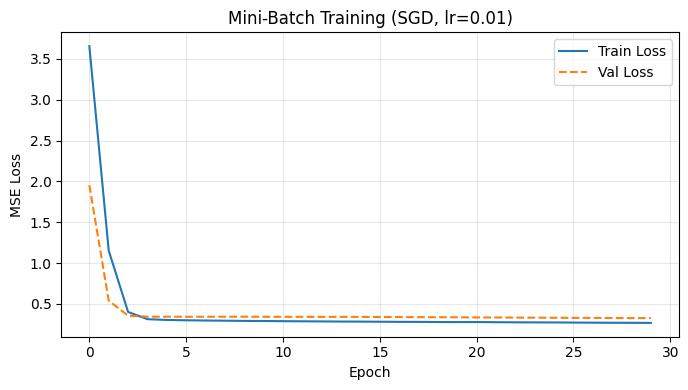

Final train loss: 0.2665 | val loss: 0.3252


In [3]:

# ── 미니배치 학습 루프 완전 예시 ──────────────────────────────────
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.fc(x).squeeze()


model     = SimpleNet()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

train_losses, val_losses = [], []

for epoch in range(30):
    # Training
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # Validation
    model.eval()
    with torch.no_grad():
        v_loss = 0
        for X_batch, y_batch in val_loader:
            pred = model(X_batch)
            v_loss += criterion(pred, y_batch).item()
        val_losses.append(v_loss / len(val_loader))

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Mini-Batch Training (SGD, lr=0.01)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final train loss: {train_losses[-1]:.4f} | val loss: {val_losses[-1]:.4f}")


---
<a id="section2"></a>
## 2. SGD의 한계와 Momentum

### 2-1. SGD의 두 가지 문제

기본 SGD는 간단하지만, 실제로 쓰기 어려운 경우가 많습니다.

**문제 1: 진동(Oscillation)**

손실 함수의 방향에 따라 gradient 크기가 크게 다를 때,  
빠른 방향으로는 크게 진동하고, 느린 방향으로는 조금씩 이동합니다.

**문제 2: 안장점(Saddle Point)에서 정체**

고차원 공간에서는 극솟값보다 안장점이 훨씬 많습니다.  
gradient가 0에 가까워지면 SGD는 그 자리에서 멈춰버립니다.

### 2-2. Momentum: 관성을 이용한 해결

Momentum은 물리학의 관성(inertia) 개념에서 영감을 받았습니다.  
공이 언덕을 굴러 내려가는 것처럼, **이전 이동 방향의 관성**을 유지합니다.

$$v_t = \beta v_{t-1} + (1 - \beta) \nabla_\theta \mathcal{L}$$

$$\theta \leftarrow \theta - \eta \cdot v_t$$

- $v_t$: 속도(velocity) — 이전 gradient들의 지수 이동 평균
- $\beta$: 관성 계수 (보통 0.9) — 이전 속도를 얼마나 유지할지
- $\eta$: 학습률

> **직관**: 경사가 일정하면 점점 빨라지고, 방향이 뒤집히면 속도가 줄어듭니다.

| 특징 | SGD | SGD + Momentum |
|------|-----|----------------|
| 안장점 탈출 | 어려움 | 관성으로 탈출 가능 |
| 진동 | 심함 | 반대 방향이 상쇄되어 줄어듦 |
| 수렴 속도 | 느림 | 빠름 |


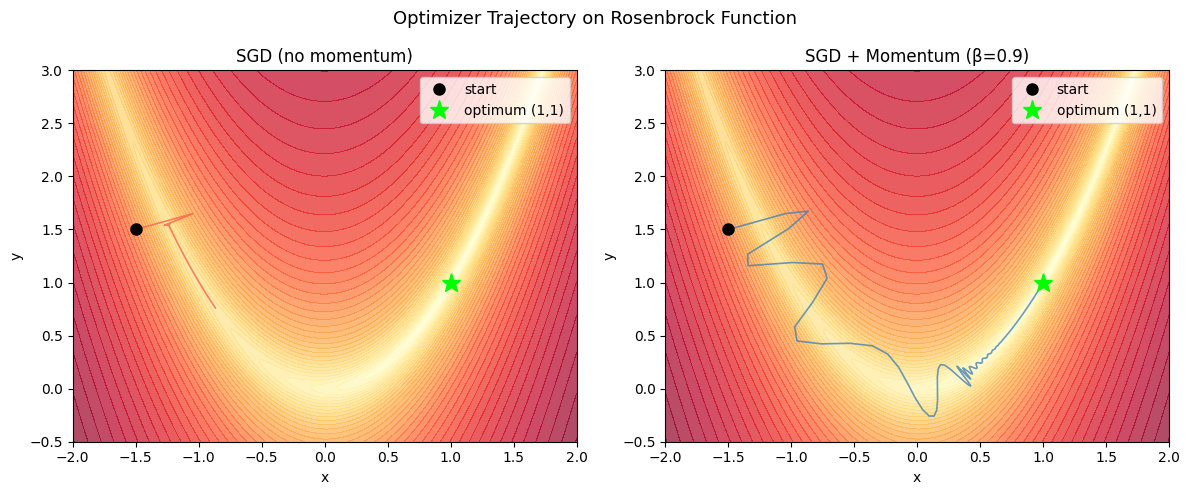

SGD final loss      : 3.4942
Momentum final loss : 0.0019


In [4]:

# ── Momentum 효과 시각화: Rosenbrock 함수 ────────────────────────
# Rosenbrock: f(x,y) = (1-x)^2 + 100*(y-x^2)^2
# 좁고 구불구불한 계곡 — SGD가 고전하는 대표적인 사례

def rosenbrock(params):
    x, y = params
    return (1 - x)**2 + 100 * (y - x**2)**2


def optimize_path(optimizer_fn, steps=500):
    # Run optimizer and record parameter trajectory.
    params = torch.tensor([-1.5, 1.5], dtype=torch.float32, requires_grad=True)
    opt = optimizer_fn([params])
    path = [params.detach().clone().numpy()]
    for _ in range(steps):
        opt.zero_grad()
        loss = rosenbrock(params)
        loss.backward()
        opt.step()
        path.append(params.detach().clone().numpy())
    return np.array(path), rosenbrock(params).item()


path_sgd,  loss_sgd  = optimize_path(lambda p: optim.SGD(p, lr=0.001))
path_mom,  loss_mom  = optimize_path(lambda p: optim.SGD(p, lr=0.001, momentum=0.9))

# ── 시각화 ────────────────────────────────────────────────────────
x_range = np.linspace(-2, 2, 300)
y_range = np.linspace(-0.5, 3, 300)
X_r, Y_r = np.meshgrid(x_range, y_range)
Z = (1 - X_r)**2 + 100 * (Y_r - X_r**2)**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, title, color in zip(
    axes,
    [path_sgd, path_mom],
    ["SGD (no momentum)", "SGD + Momentum (β=0.9)"],
    ["tomato", "steelblue"]
):
    ax.contourf(X_r, Y_r, np.log(Z + 1), levels=40, cmap="YlOrRd", alpha=0.7)
    ax.plot(path[:, 0], path[:, 1], color=color, linewidth=1.2, alpha=0.8)
    ax.plot(path[0, 0], path[0, 1], "o", color="black", markersize=8, label="start")
    ax.plot(1, 1, "*", color="lime", markersize=14, label="optimum (1,1)")
    ax.set_xlim(-2, 2); ax.set_ylim(-0.5, 3)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend()

plt.suptitle("Optimizer Trajectory on Rosenbrock Function", fontsize=13)
plt.tight_layout()
plt.show()

print(f"SGD final loss      : {loss_sgd:.4f}")
print(f"Momentum final loss : {loss_mom:.4f}")


---
<a id="section3"></a>
## 3. Adam 옵티마이저

### 3-1. Momentum의 남은 문제

Momentum은 진동을 줄이고 수렴을 빠르게 해줍니다.  
그런데 **모든 파라미터에 같은 학습률**을 적용한다는 문제가 남아 있습니다.

- 어떤 파라미터는 gradient가 항상 크고 (과도하게 업데이트)
- 어떤 파라미터는 gradient가 항상 작아서 (업데이트가 너무 느림)

### 3-2. Adam = Momentum + 적응형 학습률

**Adam (Adaptive Moment Estimation)**은 두 가지를 결합합니다:

1. **1차 모멘트** $m_t$ (Momentum과 유사): gradient의 지수 이동 평균
2. **2차 모멘트** $v_t$ (RMSProp과 유사): gradient 제곱의 지수 이동 평균

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

편향 보정 후 업데이트:

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \cdot \hat{m}_t$$

> **직관**: $\sqrt{\hat{v}_t}$로 나누기 때문에, gradient가 큰 파라미터는 학습률이 작아지고, gradient가 작은 파라미터는 학습률이 커집니다.

| 하이퍼파라미터 | 기본값 | 의미 |
|---------------|--------|------|
| $\eta$ (lr) | 0.001 | 기본 학습률 |
| $\beta_1$ | 0.9 | 1차 모멘트 감쇠율 |
| $\beta_2$ | 0.999 | 2차 모멘트 감쇠율 |
| $\epsilon$ | 1e-8 | 분모 0 방지 |

### 3-3. 왜 Adam이 널리 쓰이나?

- 초기 학습률 0.001이 대부분의 문제에서 잘 작동 (튜닝 부담 감소)
- 수렴 속도가 빠름
- 학습률에 덜 민감함

> **하지만 Adam이 항상 최선은 아닙니다.**  
> 일부 경우 SGD+Momentum이 최종 성능에서 더 좋은 결과를 내기도 합니다.  
> 실전에서는 Adam으로 시작해서 필요하면 SGD로 파인튜닝하는 방식이 많이 쓰입니다.


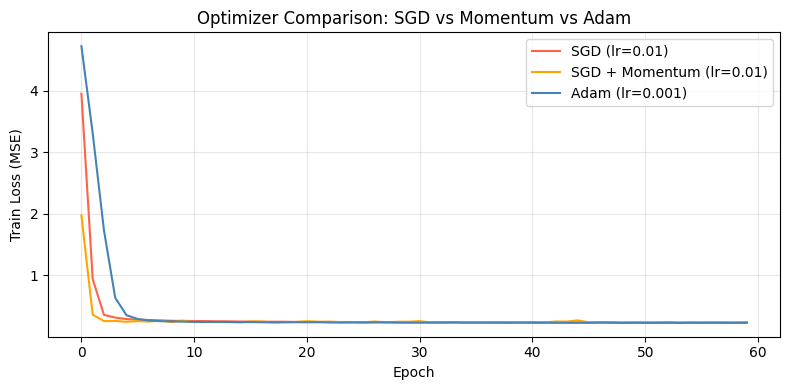

Final loss — SGD: 0.2325 | Momentum: 0.2410 | Adam: 0.2286


In [5]:

# ── 옵티마이저 비교: SGD vs Momentum vs Adam ─────────────────────
# 같은 모델, 같은 데이터, 다른 옵티마이저

def make_model():
    torch.manual_seed(0)
    return nn.Sequential(
        nn.Linear(2, 32), nn.ReLU(),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 1)
    )


def train_model(optimizer_class, **opt_kwargs):
    model = make_model()
    criterion = nn.MSELoss()
    optimizer = optimizer_class(model.parameters(), **opt_kwargs)
    losses = []
    for epoch in range(60):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch).squeeze()
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))
    return losses


losses_sgd  = train_model(optim.SGD,  lr=0.01)
losses_mom  = train_model(optim.SGD,  lr=0.01, momentum=0.9)
losses_adam = train_model(optim.Adam, lr=0.001)

plt.figure(figsize=(8, 4))
plt.plot(losses_sgd,  label="SGD (lr=0.01)",             color="tomato")
plt.plot(losses_mom,  label="SGD + Momentum (lr=0.01)",  color="orange")
plt.plot(losses_adam, label="Adam (lr=0.001)",            color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Train Loss (MSE)")
plt.title("Optimizer Comparison: SGD vs Momentum vs Adam")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss — SGD: {losses_sgd[-1]:.4f} | Momentum: {losses_mom[-1]:.4f} | Adam: {losses_adam[-1]:.4f}")


---
<a id="section4"></a>
## 4. 학습률 스케줄러 (LR Scheduler)

### 4-1. 왜 학습률을 줄여야 할까?

학습 초반에는 **큰 학습률**로 빠르게 좋은 위치에 접근하고,  
학습 후반에는 **작은 학습률**로 세밀하게 최솟값을 찾는 것이 이상적입니다.

고정 학습률의 문제:
- 너무 크면 → 최솟값 근처에서 진동, 발산 가능
- 너무 작으면 → 수렴이 매우 느림

### 4-2. 대표적인 LR 스케줄러

**StepLR**: 일정 에포크마다 고정 비율로 감소

$$\eta_t = \eta_0 \times \gamma^{\lfloor t / \text{step\_size} \rfloor}$$

**CosineAnnealingLR**: 코사인 곡선을 따라 부드럽게 감소

$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\frac{t\pi}{T}\right)$$

**ReduceLROnPlateau**: 검증 손실이 더 이상 줄지 않으면 자동으로 감소  
→ 가장 실용적, 수동 스케줄 없이도 잘 작동

### 4-3. PyTorch에서 사용하는 방법

```python
optimizer = optim.Adam(model.parameters(), lr=0.01)

# StepLR: 10에포크마다 0.5배
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

for epoch in range(num_epochs):
    # ... 학습 루프 ...
    scheduler.step()   # 에포크 끝에 호출
```

> **중요**: `scheduler.step()`은 반드시 에포크 끝에 호출합니다.  
> `ReduceLROnPlateau`는 `scheduler.step(val_loss)` 형태로 검증 손실을 전달합니다.


/tmp/ipykernel_7917/3000341207.py:23: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


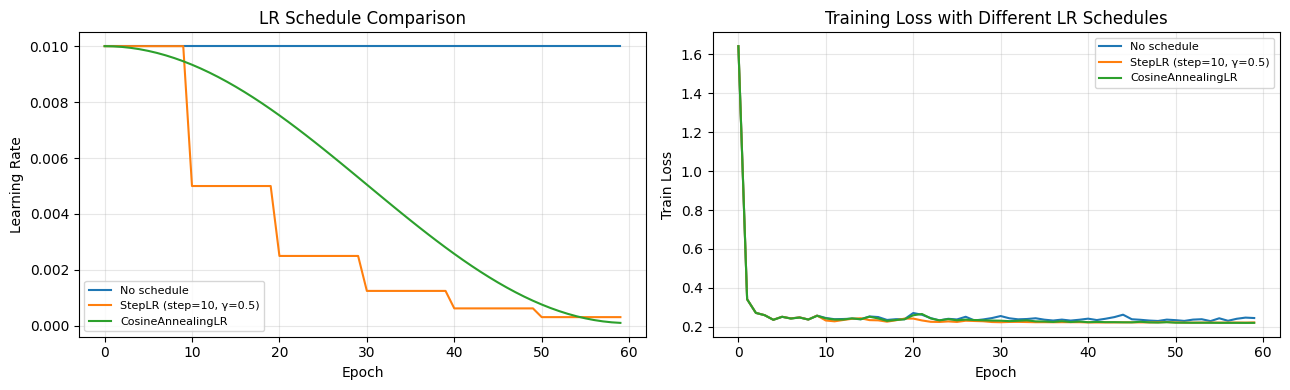

In [6]:

# ── LR Scheduler 비교 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs = 60

# ── (a) 학습률 곡선 비교 ──────────────────────────────────────────
schedulers = {
    "No schedule":          None,
    "StepLR (step=10, γ=0.5)":
        lambda opt: optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5),
    "CosineAnnealingLR":
        lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-4),
}

ax = axes[0]
for name, sched_fn in schedulers.items():
    dummy_opt = optim.Adam([torch.tensor(1.0, requires_grad=True)], lr=0.01)
    sched = sched_fn(dummy_opt) if sched_fn else None
    lrs = []
    for _ in range(epochs):
        lrs.append(dummy_opt.param_groups[0]['lr'])
        if sched:
            sched.step()
    ax.plot(lrs, label=name)

ax.set_xlabel("Epoch"); ax.set_ylabel("Learning Rate")
ax.set_title("LR Schedule Comparison")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (b) 실제 훈련 손실 비교 ──────────────────────────────────────
ax = axes[1]

def train_with_scheduler(sched_fn):
    model = make_model()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    sched = sched_fn(optimizer) if sched_fn else None
    losses = []
    for _ in range(epochs):
        model.train()
        ep_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch).squeeze()
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        losses.append(ep_loss / len(train_loader))
        if sched:
            sched.step()
    return losses

for name, sched_fn in schedulers.items():
    ax.plot(train_with_scheduler(sched_fn), label=name)

ax.set_xlabel("Epoch"); ax.set_ylabel("Train Loss")
ax.set_title("Training Loss with Different LR Schedules")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
<a id="section5"></a>
## 5. 실전 비교 실험

### 5-1. 배치 크기(Batch Size)의 영향

배치 크기도 중요한 하이퍼파라미터입니다.

| 배치 크기 | 특징 |
|-----------|------|
| 작음 (8~32) | 노이즈 많음, 일반화 잘됨, 느림 |
| 중간 (64~256) | 균형, 가장 많이 사용 |
| 큼 (1024+) | 안정적, 빠르지만 과적합 위험, 메모리 필요 |

> **실전 팁**: 배치 크기 32 또는 64로 시작하고, 메모리 여유가 있으면 늘려보세요.


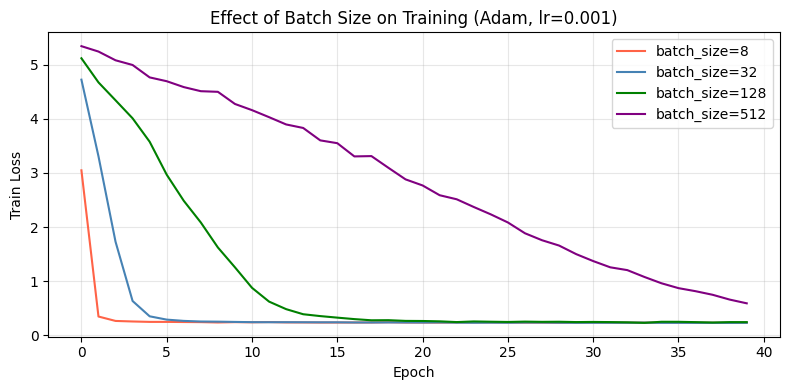

In [7]:

# ── 배치 크기별 학습 곡선 비교 ───────────────────────────────────
batch_sizes = [8, 32, 128, 512]
colors = ["tomato", "steelblue", "green", "purple"]

plt.figure(figsize=(8, 4))

for bs, color in zip(batch_sizes, colors):
    loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    model = make_model()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    losses = []
    for _ in range(40):
        model.train()
        ep_loss = 0
        for X_b, y_b in loader:
            optimizer.zero_grad()
            pred = model(X_b).squeeze()
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        losses.append(ep_loss / len(loader))
    plt.plot(losses, label=f"batch_size={bs}", color=color)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Effect of Batch Size on Training (Adam, lr=0.001)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 📌 Part 1 핵심 정리

| 개념 | 핵심 요약 |
|------|-----------|
| 미니배치 GD | 전체 데이터를 작은 배치로 나눠 업데이트 — 메모리 효율 + 빠른 수렴 |
| DataLoader | `shuffle=True` (훈련), `shuffle=False` (검증) |
| SGD | 단순하지만 진동·안장점 문제 |
| Momentum | 관성으로 진동 감소 + 안장점 탈출, β=0.9 주로 사용 |
| Adam | Momentum + 적응형 학습률, lr=0.001 기본값, 가장 널리 사용 |
| LR Scheduler | 초반 크게, 후반 작게 — StepLR / CosineAnnealingLR / ReduceLROnPlateau |

### 실전 권장 조합
```python
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
```

---
## ⏭️ 다음 주 예고 (8주차)

8주차는 **실전 딥러닝 2 + 중간고사**입니다.
- **Batch Normalization**: 레이어 간 입력 분포를 안정화하는 기법
- **Softmax 다중분류**: 2주차에서 맛보았던 softmax를 완성
- 중간고사 범위: 1~7주차 전체

> 오늘 배운 optimizer와 scheduler를 다음 주 BN 실험에서 함께 사용합니다!


---
# Part 2: 실습 (100분)

> 영상을 보고 왔다면 모두 풀 수 있습니다.  
> 막히면 Part 1 코드를 참고하세요.

## [A] 한 줄 채우기 (8문제)

각 빈칸(`______`)을 채워 코드를 완성하세요.


In [8]:

# 실습 데이터 준비
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(7)
np.random.seed(7)

N = 800
X_data = np.random.randn(N, 3).astype(np.float32)
y_data = (2*X_data[:,0] - X_data[:,1] + 0.5*X_data[:,2]
          + np.random.randn(N).astype(np.float32) * 0.3)

X_tr, X_vl = X_data[:640], X_data[640:]
y_tr, y_vl = y_data[:640], y_data[640:]

print("Data ready. X_tr:", X_tr.shape, "| y_tr:", y_tr.shape)


Data ready. X_tr: (640, 3) | y_tr: (640,)


### [A-1] TensorDataset 만들기

`TensorDataset`은 텐서를 바로 Dataset으로 만드는 가장 간단한 방법입니다.  
`X_tensor`와 `y_tensor`를 묶어 `train_dataset`을 만드세요.


In [9]:

X_tensor = torch.FloatTensor(X_tr)
y_tensor = torch.FloatTensor(y_tr)

# [A-1] TensorDataset으로 묶기
train_dataset = ______

print(f"Dataset size: {len(train_dataset)}")
print(f"Sample: {train_dataset[0]}")


NameError: name '______' is not defined

### [A-2] DataLoader 생성

`train_dataset`을 받아서 batch_size=64, 훈련용(섞기)으로 DataLoader를 만드세요.


In [ ]:

# [A-2] DataLoader 생성 (batch_size=64, 훈련용이므로 shuffle=True)
train_loader = ______

print(f"Batch count: {len(train_loader)}")
X_b, y_b = next(iter(train_loader))
print(f"Batch shape — X: {X_b.shape}, y: {y_b.shape}")


### [A-3] 검증용 DataLoader

검증 데이터는 섞지 않아야 합니다. batch_size=64로 `val_loader`를 만드세요.


In [ ]:

val_dataset = TensorDataset(torch.FloatTensor(X_vl), torch.FloatTensor(y_vl))

# [A-3] 검증용 DataLoader (shuffle=False)
val_loader = ______

print(f"Val batch count: {len(val_loader)}")


### [A-4] SGD + Momentum 옵티마이저

아래 모델에 `SGD` 옵티마이저를 `lr=0.01`, `momentum=0.9`로 설정하세요.


In [ ]:

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(3, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.layers(x).squeeze()

model_mom = Net()

# [A-4] SGD + Momentum 옵티마이저 (lr=0.01, momentum=0.9)
optimizer_mom = ______

print(optimizer_mom)


### [A-5] Adam 옵티마이저

같은 모델 구조로 `Adam` 옵티마이저를 `lr=0.001`로 설정하세요.


In [ ]:

model_adam = Net()

# [A-5] Adam 옵티마이저 (lr=0.001)
optimizer_adam = ______

print(optimizer_adam)


### [A-6] 미니배치 학습 루프 — backward

아래 학습 루프에서 `backward()`를 호출하는 빈칸을 채우세요.


In [ ]:

criterion = nn.MSELoss()

model_tmp = Net()
opt_tmp   = optim.Adam(model_tmp.parameters(), lr=0.001)
losses_tmp = []

for epoch in range(5):
    model_tmp.train()
    ep_loss = 0
    for X_b, y_b in train_loader:
        opt_tmp.zero_grad()
        pred = model_tmp(X_b)
        loss = criterion(pred, y_b)
        # [A-6] gradient 계산 (backward pass)
        ______
        opt_tmp.step()
        ep_loss += loss.item()
    losses_tmp.append(ep_loss / len(train_loader))

print("5-epoch losses:", [f"{l:.4f}" for l in losses_tmp])


### [A-7] StepLR 스케줄러

Adam 옵티마이저에 `StepLR` 스케줄러를 연결하세요.  
조건: `step_size=10`, `gamma=0.5`


In [ ]:

model_sched = Net()
optimizer_s = optim.Adam(model_sched.parameters(), lr=0.01)

# [A-7] StepLR 스케줄러 (step_size=10, gamma=0.5)
scheduler = ______

# 현재 lr 확인
print(f"Initial lr: {optimizer_s.param_groups[0]['lr']}")
for _ in range(10):
    scheduler.step()
print(f"After 10 steps lr: {optimizer_s.param_groups[0]['lr']:.6f}")


### [A-8] no_grad 컨텍스트 

검증 루프에서 gradient 계산을 비활성화하는 컨텍스트 매니저를 채우세요.  
(`torch.no_grad()`)


In [ ]:

model_eval = Net()
criterion  = nn.MSELoss()

# 간단히 가중치를 초기 상태 그대로 검증
model_eval.eval()
# [A-8] gradient 계산 비활성화 컨텍스트
with ______:
    total_loss = 0
    for X_b, y_b in val_loader:
        pred = model_eval(X_b)
        total_loss += criterion(pred, y_b).item()
    avg_val_loss = total_loss / len(val_loader)

print(f"Validation loss: {avg_val_loss:.4f}")


---
## [B] 여러 줄 채우기 (2문제)


### [B-1] 완전한 미니배치 학습 루프 구현

아래의 `빈칸` 부분을 채워 **훈련 + 검증**이 포함된 완전한 학습 루프를 완성하세요.

힌트:
- 훈련 단계: `model.train()` → zero_grad → forward → loss → backward → step
- 검증 단계: `model.eval()` + `torch.no_grad()`
- 스케줄러: 에포크 끝에 `scheduler.step()` 호출


In [ ]:

# 모델, 옵티마이저, 스케줄러, 손실함수 준비
torch.manual_seed(42)
model_b1   = Net()
opt_b1     = optim.Adam(model_b1.parameters(), lr=0.01)
sched_b1   = optim.lr_scheduler.StepLR(opt_b1, step_size=15, gamma=0.5)
crit_b1    = nn.MSELoss()
num_epochs = 50

train_hist, val_hist, lr_hist = [], [], []

for epoch in range(num_epochs):
    # ── 훈련 ──────────────────────────────────────
    ______
    ep_tr = 0
    for X_b, y_b in train_loader:
        ______
        pred = model_b1(X_b)
        loss = crit_b1(pred, y_b)
        ______
        ______
        ep_tr += loss.item()
    train_hist.append(ep_tr / len(train_loader))

    # ── 검증 ──────────────────────────────────────
    ______
    with torch.no_grad():
        ep_vl = 0
        for X_b, y_b in val_loader:
            pred = model_b1(X_b)
            ep_vl += crit_b1(pred, y_b).item()
        val_hist.append(ep_vl / len(val_loader))

    # 현재 lr 기록
    lr_hist.append(opt_b1.param_groups[0]['lr'])
    ______  # 스케줄러 업데이트

# ── 결과 시각화 ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_hist, label="Train Loss")
ax1.plot(val_hist,   label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("B-1: Training Curve"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(lr_hist, color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
ax2.set_title("B-1: LR Schedule (StepLR)"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Best val loss: {min(val_hist):.4f} at epoch {val_hist.index(min(val_hist))+1}")


### [B-2] 옵티마이저·스케줄러 조합 비교 실험 (숙제 가능)

세 가지 설정을 비교하는 실험을 완성하세요.

| 설정 | 옵티마이저 | 스케줄러 |
|------|-----------|---------|
| A | SGD, lr=0.01, momentum=0.9 | 없음 |
| B | Adam, lr=0.001 | 없음 |
| C | Adam, lr=0.01 | CosineAnnealingLR (T_max=60) |

힌트:
- 각 설정마다 새 모델(`Net()`)을 만들어야 합니다 (가중치 공유 방지)
- 60 에포크 훈련
- 마지막 셀에서 세 곡선을 하나의 그래프에 그리기


In [ ]:

configs = {
    "A: SGD+Momentum": {
        "opt_fn":   lambda p: optim.SGD(p, lr=0.01, momentum=0.9),
        "sched_fn": None,
    },
    "B: Adam":         {
        "opt_fn":   lambda p: optim.Adam(p, lr=0.001),
        "sched_fn": None,
    },
    "C: Adam+Cosine":  {
        "opt_fn":   lambda p: optim.Adam(p, lr=0.01),
        "sched_fn": lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=60),
    },
}

results = {}
num_epochs = 60

for name, cfg in configs.items():
    torch.manual_seed(0)
    ______  # 새 모델 생성
    ______  # 옵티마이저 생성
    sched = cfg["sched_fn"](opt) if cfg["sched_fn"] else None
    crit  = nn.MSELoss()
    losses = []

    for _ in range(num_epochs):
        model.train()
        ep = 0
        for X_b, y_b in train_loader:
            opt.zero_grad()
            ______   # forward
            ______   # loss
            ______   # backward
            opt.step()
            ep += loss.item()
        losses.append(ep / len(train_loader))
        if sched:
            sched.step()

    results[name] = losses

# ── 시각화 ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch"); plt.ylabel("Train Loss")
plt.title("B-2: Optimizer & Scheduler Comparison")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for name, losses in results.items():
    print(f"{name}: final loss = {losses[-1]:.4f}")


---
## ✅ 체크리스트

- [ ] DataLoader의 `shuffle` 옵션 — 훈련: True, 검증: False 이유를 설명할 수 있다
- [ ] `zero_grad()` → `backward()` → `step()` 순서를 외웠다
- [ ] Momentum과 Adam의 차이를 한 문장으로 설명할 수 있다
- [ ] `scheduler.step()`을 에포크 끝에 호출해야 하는 이유를 안다
- [ ] `model.eval()` + `torch.no_grad()`를 검증 루프에서 쓰는 이유를 안다

---
## 💬 생각해볼 질문

1. **배치 크기가 매우 작으면 (예: 1) 어떤 문제가 생길까?** Gradient 노이즈와 수렴 안정성 측면에서 생각해 보세요.

2. **Adam을 쓰는데도 lr을 줄여야 할까?** Adam은 이미 적응형 학습률을 사용하는데, 그럼에도 LR Scheduler를 함께 쓰는 이유가 무엇일까요?

3. **검증 손실이 줄지 않을 때 첫 번째로 확인해야 할 것은?** Optimizer, LR, 모델 구조, 데이터 중 어디서부터 확인하는 게 좋을까요?
